2025-11-29 14:22:40.762717: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-29 14:22:42.976629: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764418963.177690    6352 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764418963.226107    6352 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-29 14:22:43.764446: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Shapes:
X_train: (41427, 24, 35) y_train: (41427,)
X_test : (8713, 24, 35) y_test : (8713,)
X_eval : (5785, 24, 35) y_eval : (5785,)


I0000 00:00:1764418970.871636    6352 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 31141 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:8a:00.0, compute capability: 7.0


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 64)             │        19,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

...

 Trainable params: 21,505 (84.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40


I0000 00:00:1764418975.182238    7484 cuda_dnn.cc:529] Loaded cuDNN version 90501


648/648 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.3711 - mae: 0.3271 - val_loss: 0.0690 - val_mae: 0.1325
Epoch 2/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0262 - mae: 0.0778 - val_loss: 0.0620 - val_mae: 0.1226
Epoch 3/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0222 - mae: 0.0662 - val_loss: 0.0662 - val_mae: 0.1297
Epoch 4/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0201 - mae: 0.0612 - val_loss: 0.0649 - val_mae: 0.1258
Epoch 5/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0201 - mae: 0.0636 - val_loss: 0.0600 - val_mae: 0.1208
Epoch 6/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0207 - mae: 0.0589 - val_loss: 0.0582 - val_mae: 0.1149
Epoch 7/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0211 - mae: 0.0590 - val_loss: 0.0497 - val_mae: 0.0924
Epoch 8/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0205 - mae: 0.0553 - val_loss: 0.0502 - val_mae: 0.0920
Epoch 9/40
648/648 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.0192 

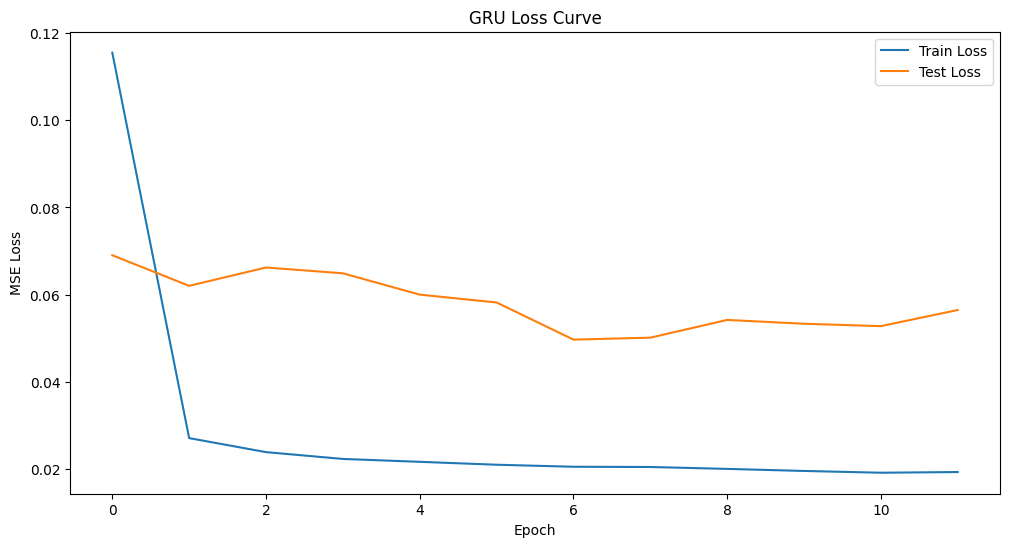


Plotting dynamic segment starting at index 200
181/181 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


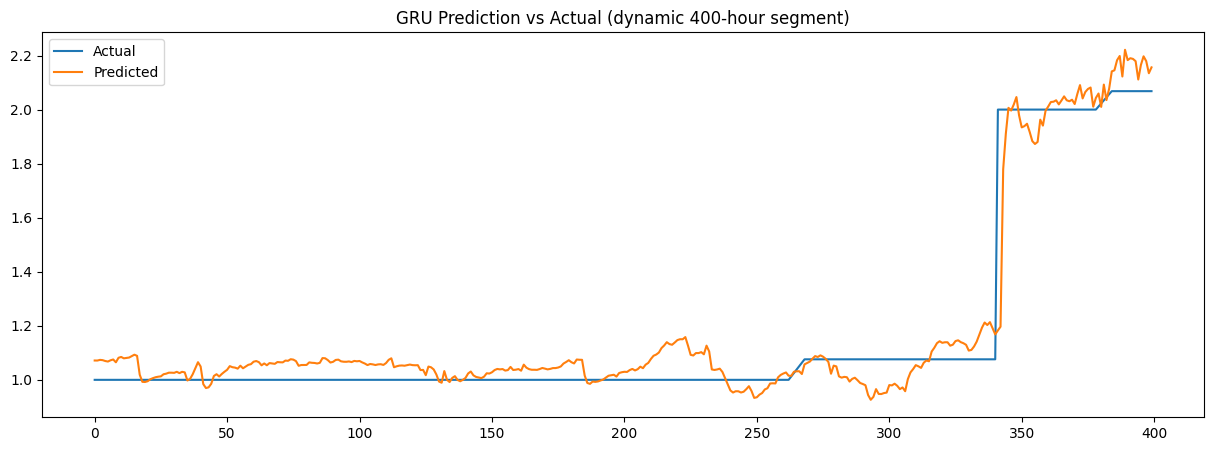


GRU model saved as gru_model.keras


In [1]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models, callbacks

# ============================================================
# 1. LOAD DATA
# ============================================================

X_train = np.load("X_train.npy")
y_train = np.load("y_train.npy")

X_test  = np.load("X_test.npy")
y_test  = np.load("y_test.npy")

X_eval  = np.load("X_eval.npy")
y_eval  = np.load("y_eval.npy")

print("Shapes:")
print("X_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test :", X_test.shape,  "y_test :", y_test.shape)
print("X_eval :", X_eval.shape,  "y_eval :", y_eval.shape)

timesteps = X_train.shape[1]   # 24
features  = X_train.shape[2]   # 35


# ============================================================
# 2. BUILD GRU MODEL
# ============================================================

def build_gru():
    model = models.Sequential([
        layers.Input(shape=(timesteps, features)),

        # First GRU layer
        layers.GRU(64, return_sequences=False, activation="tanh"),

        # Dense layers
        layers.Dense(32, activation="relu"),
        layers.Dense(1)  # Predict next-hour consumption
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
        loss="mse",
        metrics=["mae"]
    )

    return model

model = build_gru()
model.summary()


# ============================================================
# 3. TRAIN GRU MODEL WITH EARLY STOPPING
# ============================================================

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=40,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


# ============================================================
# 4. EVALUATE ON EVALUATION SET
# ============================================================

eval_results = model.evaluate(X_eval, y_eval, verbose=1)
print("\nGRU Evaluation on Eval Set:", eval_results)
# [loss, mae]


# ============================================================
# 5. PLOT TRAINING CURVE
# ============================================================

plt.figure(figsize=(12, 6))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Test Loss")
plt.title("GRU Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.show()


# ============================================================
# 6. SMART PREDICTION PLOT
#    (auto-detects a non-flat segment from eval data)
# ============================================================

# Find a region where y_eval varies more than ±0.05 kWh
window = 400   # look for 400-hour segments
start_idx = 0
for i in range(0, len(y_eval)-window, 100):
    segment = y_eval[i:i+window]
    if segment.max() - segment.min() > 0.15:
        start_idx = i
        break

print(f"\nPlotting dynamic segment starting at index {start_idx}")

y_pred = model.predict(X_eval).flatten()

plt.figure(figsize=(15,5))
plt.plot(y_eval[start_idx:start_idx+400], label="Actual")
plt.plot(y_pred[start_idx:start_idx+400], label="Predicted")
plt.title("GRU Prediction vs Actual (dynamic 400-hour segment)")
plt.legend()
plt.show()


# ============================================================
# 7. SAVE MODEL IN RECOMMENDED FORMAT
# ============================================================

model.save("gru_model.keras")   # safer than .h5
print("\nGRU model saved as gru_model.keras")


2025-11-30 13:53:35.771587: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-30 13:53:35.797620: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1764503615.813362 2921651 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1764503615.818224 2921651 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-11-30 13:53:35.834460: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

Loading GRU model...


I0000 00:00:1764503617.781126 2921651 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 468 MB memory:  -> device: 0, name: Tesla V100-SXM2-32GB, pci bus id: 0000:61:00.0, compute capability: 7.0


Loading X_eval and y_eval...
Shapes:
X_eval: (5785, 24, 35)
y_eval: (5785,)
Generating predictions...


I0000 00:00:1764503618.664841 2931785 cuda_dnn.cc:529] Loaded cuDNN version 90501


181/181 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Predictions saved as y_pred_gru.npy


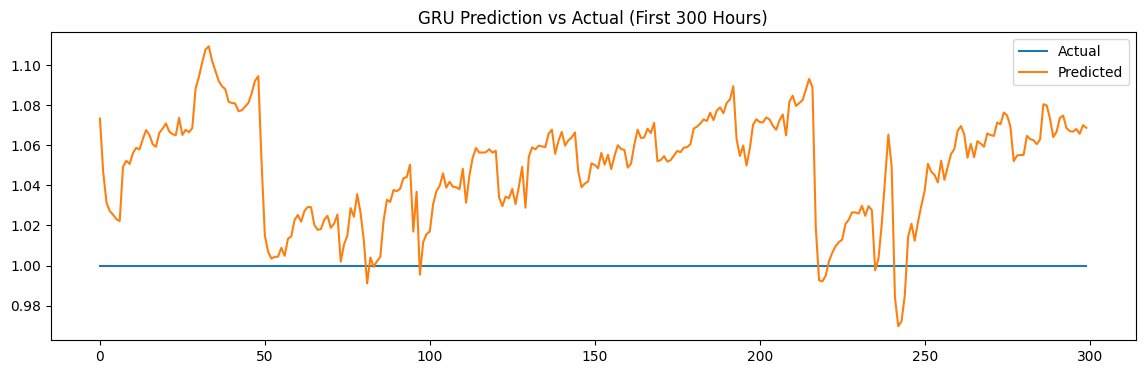

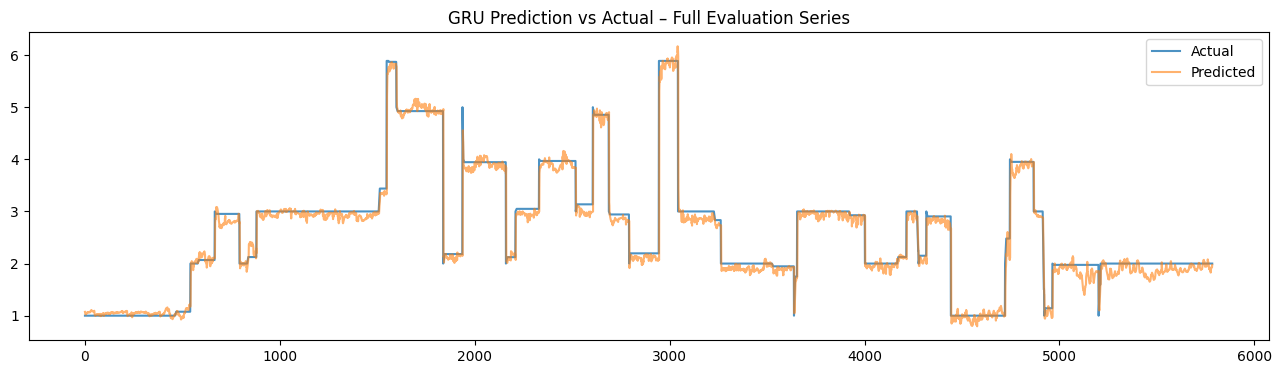

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

# --------------------------------------------------------
# 1. Load Saved GRU Model
# --------------------------------------------------------
print("Loading GRU model...")
model = tf.keras.models.load_model("gru_model.keras")

# --------------------------------------------------------
# 2. Load Preprocessed Windowed Data
# --------------------------------------------------------
print("Loading X_eval and y_eval...")
X_eval = np.load("X_eval.npy")
y_eval = np.load("y_eval.npy")

print("Shapes:")
print("X_eval:", X_eval.shape)
print("y_eval:", y_eval.shape)

# --------------------------------------------------------
# 3. Run Predictions
# --------------------------------------------------------
print("Generating predictions...")
y_pred = model.predict(X_eval, verbose=1)

# Flatten predictions if needed (Keras outputs shape (n, 1))
y_pred = y_pred.reshape(-1)

# Save predictions to a file (for plots and documentation)
np.save("y_pred_gru.npy", y_pred)

print("Predictions saved as y_pred_gru.npy")

# --------------------------------------------------------
# 4. Plot FIRST 300 HOURS (quick check)
# --------------------------------------------------------
plt.figure(figsize=(14,4))
plt.plot(y_eval[:300], label="Actual")
plt.plot(y_pred[:300], label="Predicted")
plt.title("GRU Prediction vs Actual (First 300 Hours)")
plt.legend()
plt.show()

# --------------------------------------------------------
# 5. Plot FULL Test/Eval Curve
# --------------------------------------------------------
plt.figure(figsize=(16,4))
plt.plot(y_eval, label="Actual", alpha=0.8)
plt.plot(y_pred, label="Predicted", alpha=0.6)
plt.title("GRU Prediction vs Actual – Full Evaluation Series")
plt.legend()
plt.show()


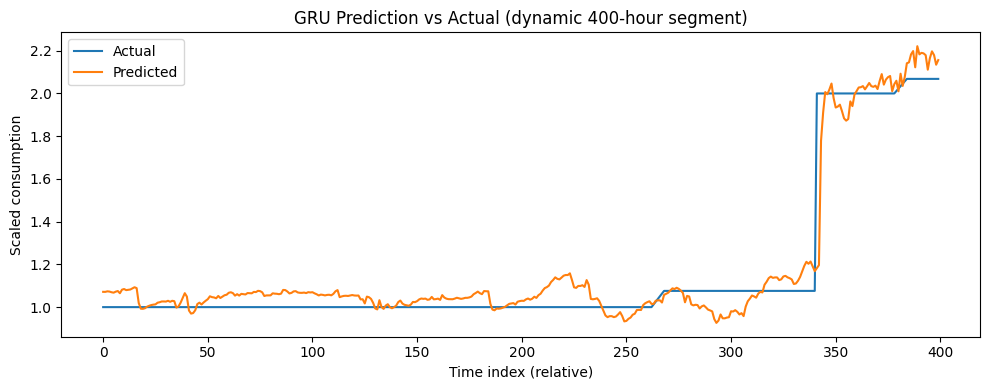

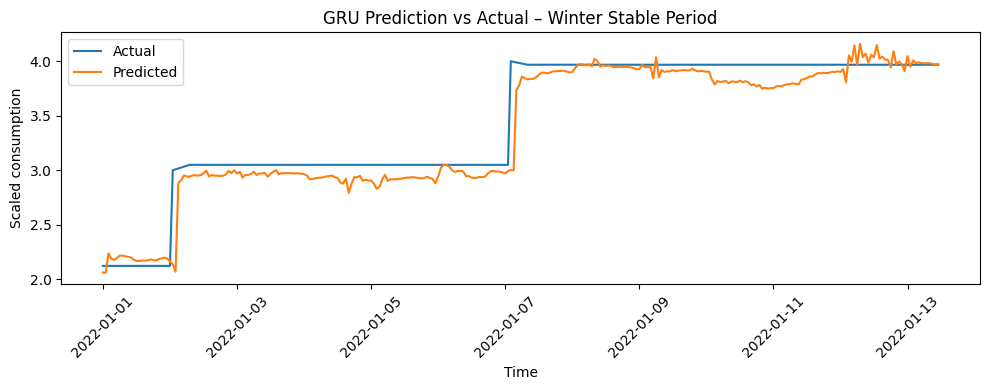

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths (adjust if needed)
X_EVAL_PATH = "X_eval.npy"
Y_EVAL_PATH = "y_eval.npy"
Y_PRED_PATH = "y_pred_gru.npy"
DATA_CSV_PATH = "dataset_mansion_features_FINAL.csv"

# Load arrays and dataset
X_eval = np.load(X_EVAL_PATH)
y_eval = np.load(Y_EVAL_PATH)
y_pred = np.load(Y_PRED_PATH)
df = pd.read_csv(DATA_CSV_PATH, parse_dates=["MTime"])

# ---------- Plot 1: Zoomed 400-hour segment ----------
start = 200
window = 400

plt.figure(figsize=(10, 4))
plt.plot(y_eval[start:start+window], label="Actual")
plt.plot(y_pred[start:start+window], label="Predicted")
plt.title("GRU Prediction vs Actual (dynamic 400-hour segment)")
plt.xlabel("Time index (relative)")
plt.ylabel("Scaled consumption")
plt.legend()
plt.tight_layout()
plt.savefig("gru_zoomed_segment.png", dpi=200)
plt.show()

# ---------- Plot 2: Winter stable period ----------
df_eval = df[(df["MTime"] >= "2021-10-01") & (df["MTime"] <= "2022-05-31")].sort_values("MTime")

# Align timestamps with y_eval length
if len(df_eval) >= len(y_eval):
    df_eval_aligned = df_eval.tail(len(y_eval)).copy()
else:
    df_eval_aligned = df_eval.copy()
    y_eval = y_eval[-len(df_eval_aligned):]
    y_pred = y_pred[-len(df_eval_aligned):]

df_eval_aligned["actual"] = y_eval[:len(df_eval_aligned)]
df_eval_aligned["pred"] = y_pred[:len(df_eval_aligned)]

winter_df = df_eval_aligned[df_eval_aligned["MTime"].dt.month.isin([1, 2])]
winter_window = 300
winter_slice = winter_df.head(winter_window)

plt.figure(figsize=(10, 4))
plt.plot(winter_slice["MTime"], winter_slice["actual"], label="Actual")
plt.plot(winter_slice["MTime"], winter_slice["pred"], label="Predicted")
plt.title("GRU Prediction vs Actual – Winter Stable Period")
plt.xlabel("Time")
plt.ylabel("Scaled consumption")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig("gru_winter_segment.png", dpi=200)
plt.show()
